In [114]:
#Cell 1 — Importing all the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import shap
import joblib
import os

In [115]:
#Cell 2 — Loading the datasets

objects = pd.read_csv("objects.csv")
funding = pd.read_csv("funding_rounds.csv")
ipos = pd.read_csv("ipos.csv")
acquisitions = pd.read_csv("acquisitions.csv")

print("Objects:", objects.shape)
print("Funding:", funding.shape)
print("IPOs:", ipos.shape)
print("Acquisitions:", acquisitions.shape)

C:\Users\meetc\AppData\Local\Temp\ipykernel_16468\1950827183.py:3: DtypeWarning: Columns (3,7,9,10,17,18,21,22,23,25,26,29,30,37) have mixed types. Specify dtype option on import or set low_memory=False.
  objects = pd.read_csv("objects.csv")


Objects: (462651, 40)
Funding: (52928, 23)
IPOs: (1259, 13)
Acquisitions: (9562, 12)


In [116]:
#Cell 3 — Creating and defining the target variable

ipo_ids = set(ipos['object_id'])
acq_ids = set(acquisitions['acquired_object_id'])
successful_ids = ipo_ids.union(acq_ids)

objects['success'] = objects['id'].isin(successful_ids).astype(int)

print("Success Distribution:")
print(objects['success'].value_counts())

Success Distribution:
success
0    452123
1     10528
Name: count, dtype: int64


In [117]:
#Cell 4 — Filtering for companies and analyzing the target variable distribution

companies = objects[objects['entity_type'] == 'Company'].copy()

print("Companies shape:", companies.shape)
print("\nSuccess Distribution in Companies:")
print(companies['success'].value_counts())

Companies shape: (196553, 41)

Success Distribution in Companies:
success
0    186025
1     10528
Name: count, dtype: int64


In [118]:
#Cell 5 — Handling missing values 
# Date
companies['founded_at'] = pd.to_datetime(companies['founded_at'], errors='coerce')
companies['company_age'] = 2024 - companies['founded_at'].dt.year
companies['company_age'] = companies['company_age'].fillna(companies['company_age'].median())

# Funding — fill before log transform
companies['funding_total_usd'] = companies['funding_total_usd'].fillna(0)
companies['log_funding_total_usd'] = np.log1p(companies['funding_total_usd'])

# Categorical
companies['category_code'] = companies['category_code'].fillna('Unknown')
companies['country_code'] = companies['country_code'].fillna('Unknown')

print("Missing values after cleaning:")
print(companies[['company_age', 'log_funding_total_usd', 
                  'category_code', 'country_code']].isnull().sum())

Missing values after cleaning:
company_age              0
log_funding_total_usd    0
category_code            0
country_code             0
dtype: int64


In [119]:
# ---- Cell 5 - Clean Data & Handle Missing Values ----

# Use clean data only (remove Unknown country)
companies_clean = companies[companies['country_code'] != 'Unknown'].copy()

# Convert all date columns
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at',
             'first_milestone_at', 'last_milestone_at']
for col in date_cols:
    companies_clean[col] = pd.to_datetime(companies_clean[col], errors='coerce')

# Company age
companies_clean['company_age'] = 2024 - companies_clean['founded_at'].dt.year
companies_clean['company_age'] = companies_clean['company_age'].fillna(
    companies_clean['company_age'].median()
)

# Funding duration (months between first and last funding)
companies_clean['funding_duration_days'] = (
    companies_clean['last_funding_at'] - companies_clean['first_funding_at']
).dt.days
companies_clean['funding_duration_days'] = companies_clean['funding_duration_days'].fillna(0)

# Milestone duration (months between first and last milestone)
companies_clean['milestone_duration_days'] = (
    companies_clean['last_milestone_at'] - companies_clean['first_milestone_at']
).dt.days
companies_clean['milestone_duration_days'] = companies_clean['milestone_duration_days'].fillna(0)

# Time to first funding (how quickly did they get funded)
companies_clean['days_to_first_funding'] = (
    companies_clean['first_funding_at'] - companies_clean['founded_at']
).dt.days
companies_clean['days_to_first_funding'] = companies_clean['days_to_first_funding'].fillna(
    companies_clean['days_to_first_funding'].median()
)

# Funding per round (efficiency metric)
companies_clean['funding_total_usd'] = companies_clean['funding_total_usd'].fillna(0)
companies_clean['log_funding_total_usd'] = np.log1p(companies_clean['funding_total_usd'])
companies_clean['funding_per_round'] = companies_clean.apply(
    lambda x: x['funding_total_usd'] / x['funding_rounds'] 
    if x['funding_rounds'] > 0 else 0, axis=1
)
companies_clean['log_funding_per_round'] = np.log1p(companies_clean['funding_per_round'])

# Is Silicon Valley (USA + CA state)
companies_clean['state_code'] = companies_clean['state_code'].fillna('Unknown')
companies_clean['is_silicon_valley'] = (
    (companies_clean['country_code'] == 'USA') & 
    (companies_clean['state_code'] == 'CA')
).astype(int)

# Has website (basic credibility signal)
companies_clean['has_website'] = companies_clean['homepage_url'].notna().astype(int)

# Has description (another credibility signal)
companies_clean['has_description'] = companies_clean['description'].notna().astype(int)

# Category and country
companies_clean['category_code'] = companies_clean['category_code'].fillna('Unknown')

print("Features engineered successfully!")
print("Clean dataset shape:", companies_clean.shape)
print("\nSuccess distribution:")
print(companies_clean['success'].value_counts())

Features engineered successfully!
Clean dataset shape: (87990, 51)

Success distribution:
success
0    80224
1     7766
Name: count, dtype: int64


In [120]:
# Cell 6 - Encode & Build Feature Matrix ----

# Group rare countries
top_countries = companies_clean['country_code'].value_counts().head(10).index
companies_clean['country_code_grouped'] = companies_clean['country_code'].apply(
    lambda x: x if x in top_countries else 'Other'
)

# Encode categoricals
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(
    companies_clean[['category_code', 'country_code_grouped']]
)
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['category_code', 'country_code_grouped'])
).reset_index(drop=True)

# Numeric features — now with new engineered features
numeric_features = companies_clean[[
    'company_age',
    'log_funding_total_usd',
    'funding_rounds',
    'milestones',
    'relationships',
    'investment_rounds',
    'funding_duration_days',
    'milestone_duration_days',
    'days_to_first_funding',
    'log_funding_per_round',
    'is_silicon_valley',
    'has_website',
    'has_description'
]].reset_index(drop=True)

X = pd.concat([numeric_features, encoded_df], axis=1)
y = companies_clean['success'].reset_index(drop=True)

print("Final feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Final feature matrix shape: (87990, 67)
Target distribution:
success
0    80224
1     7766
Name: count, dtype: int64


In [121]:
# Cell 7 - Train-Test Split with Stratification 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))

Train size: (70392, 67)
Test size: (17598, 67)

Train target distribution:
success
0    0.9117
1    0.0883
Name: proportion, dtype: float64


In [122]:
# Cell 8 - Evaluate Model Performance(Retrain XGBoost With SMOTE to handle class imbalance)

from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts())

Before SMOTE: success
0    64179
1     6213
Name: count, dtype: int64
After SMOTE: success
0    64179
1    64179
Name: count, dtype: int64


In [123]:
# Cell 9 - Train XGBoost and Evaluate

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

# Check average probability for actual successes
success_probs = xgb_model.predict_proba(X_test[y_test==1])[:,1]
print("\nAvg probability for actual successes:", success_probs.mean().round(4))
print("Min:", success_probs.min().round(4))
print("Max:", success_probs.max().round(4))

[0]	validation_0-auc:0.76329
[50]	validation_0-auc:0.80302
[100]	validation_0-auc:0.80871
[150]	validation_0-auc:0.81160
[200]	validation_0-auc:0.81482
[250]	validation_0-auc:0.81709
[299]	validation_0-auc:0.81813

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     16045
           1       0.32      0.42      0.36      1553

    accuracy                           0.87     17598
   macro avg       0.63      0.67      0.65     17598
weighted avg       0.89      0.87      0.88     17598

ROC-AUC: 0.8181328792552016

Avg probability for actual successes: 0.4379
Min: 0.0041
Max: 0.9735


In [124]:
#Cell 10 — Threshold tuning for XGBoost using Precision-Recall curve(to optimize F1 score)/find the best threshold for classification based on F1 score

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", round(best_threshold, 4))
print("Best F1:", round(f1[best_idx], 4))

Best Threshold: 0.389
Best F1: 0.3844


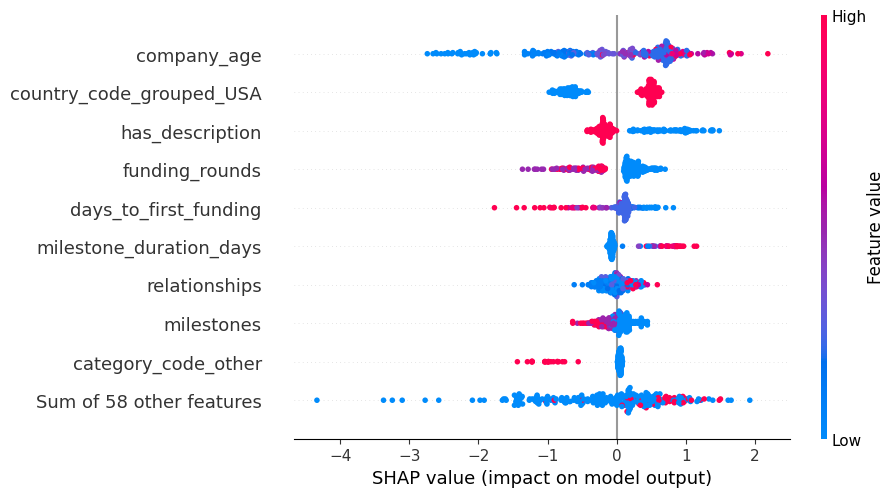

<Figure size 640x480 with 0 Axes>

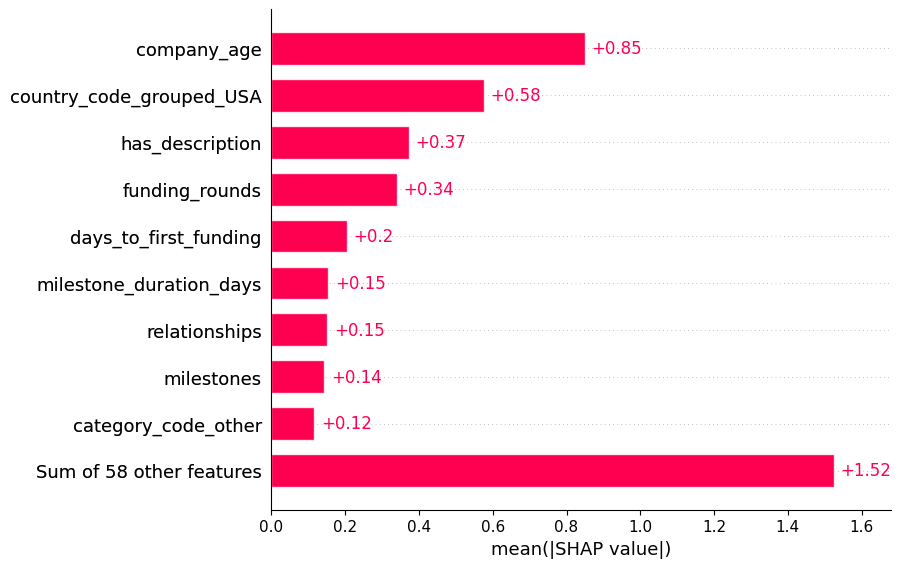

<Figure size 640x480 with 0 Axes>

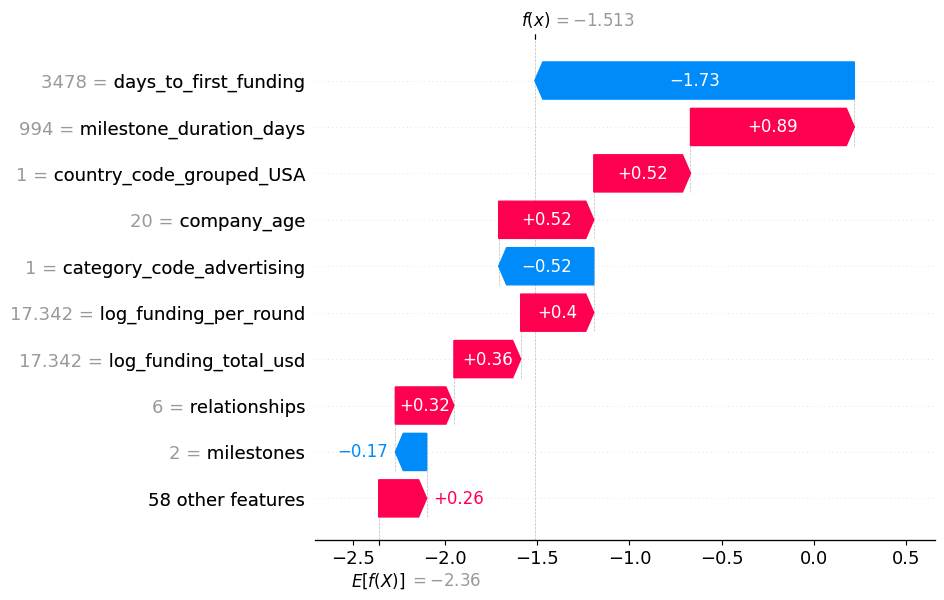

In [125]:
#Cell 11 — SHAP explanations for XGBoost model

X_sample = X_test.sample(300, random_state=42)

explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_sample)

# Global feature importance
shap.plots.beeswarm(shap_values)
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot
shap.plots.bar(shap_values)
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Single prediction explanation
single = X_test.iloc[[0]]
shap_single = explainer(single)
shap.plots.waterfall(shap_single[0])
plt.show()

In [126]:
#Cell 12 — Saving the best model and preprocessing objects

os.makedirs("models", exist_ok=True)

joblib.dump({
    "model": xgb_model,
    "features": X_train.columns.tolist(),
    "threshold": best_threshold,
    "encoder": encoder
}, "models/startup_success_model.pkl")

print("Model saved successfully!")
print("Files in models folder:", os.listdir("models"))

Model saved successfully!
Files in models folder: ['startup_success_model.pkl']


In [127]:
import os
print("Files in models folder:", os.listdir("models"))

Files in models folder: ['startup_success_model.pkl']


In [128]:
# Check what exact country codes and categories are in your encoder
print("Categories in encoder:")
print(encoder.categories_)

Categories in encoder:
[array(['Unknown', 'advertising', 'analytics', 'automotive', 'biotech',
       'cleantech', 'consulting', 'design', 'ecommerce', 'education',
       'enterprise', 'fashion', 'finance', 'games_video', 'government',
       'hardware', 'health', 'hospitality', 'legal', 'local',
       'manufacturing', 'medical', 'messaging', 'mobile', 'music',
       'nanotech', 'network_hosting', 'news', 'nonprofit', 'other',
       'pets', 'photo_video', 'public_relations', 'real_estate', 'search',
       'security', 'semiconductor', 'social', 'software', 'sports',
       'transportation', 'travel', 'web'], dtype=object), array(['AUS', 'CAN', 'DEU', 'ESP', 'FRA', 'GBR', 'IND', 'IRL', 'ISR',
       'Other', 'USA'], dtype=object)]


In [129]:
# Check the feature names generated by the encoder

# Check if encoder was saved properly in your model
artifact = joblib.load("models/startup_success_model.pkl")
print(artifact.keys())
print(type(artifact['encoder']))

dict_keys(['model', 'features', 'threshold', 'encoder'])
<class 'sklearn.preprocessing._encoders.OneHotEncoder'>


In [130]:
# Check the feature names generated by the encoder

print("Classes:", xgb_model.classes_)
print("\nValue counts of y_train:")
print(y_train.value_counts())
print("\nSample predictions:")
sample = X_test.iloc[:5]
print("Probabilities:", xgb_model.predict_proba(sample))
print("Actual labels:", y_test.iloc[:5].values)

Classes: [0 1]

Value counts of y_train:
success
0    64179
1     6213
Name: count, dtype: int64

Sample predictions:
Probabilities: [[0.81953526 0.18046476]
 [0.80860037 0.19139962]
 [0.9919849  0.00801508]
 [0.81343853 0.18656147]
 [0.95787984 0.04212013]]
Actual labels: [0 0 0 0 0]


In [131]:
# Check what a clearly successful startup looks like
successful = X_test[y_test == 1].iloc[[0]]
print("Successful startup proba:", xgb_model.predict_proba(successful))

# Check what a failed startup looks like  
failed = X_test[y_test == 0].iloc[[0]]
print("Failed startup proba:", xgb_model.predict_proba(failed))

Successful startup proba: [[0.17057669 0.8294233 ]]
Failed startup proba: [[0.81953526 0.18046476]]


In [132]:
import joblib

artifact = joblib.load("models/startup_success_model.pkl")
threshold = artifact["threshold"]

print("Your threshold:", threshold)

Your threshold: 0.38898793


In [133]:
# See what probabilities successful startups actually get
successful_probs = xgb_model.predict_proba(X_test[y_test==1])[:,1]
print("Average success probability for actual successes:", successful_probs.mean())
print("Min:", successful_probs.min())
print("Max:", successful_probs.max())

Average success probability for actual successes: 0.43788928
Min: 0.0041280086
Max: 0.97354716


In [134]:
joblib.dump({
    "model": xgb_model,
    "features": X_train.columns.tolist(),
    "threshold": best_threshold,
    "encoder": encoder
}, "models/startup_success_model.pkl")

print("Model resaved with new threshold:", best_threshold)

Model resaved with new threshold: 0.38898793


In [135]:
# Simulate exactly what second case looks like
import pandas as pd
import numpy as np

test_case = {
    "company_age": 1,
    "log_funding_total_usd": np.log1p(0),
    "funding_rounds": 0,
    "milestones": 0,
    "relationships": 0,
    "investment_rounds": 0
}

cat_df = pd.DataFrame([['consulting', 'IND']], 
                       columns=['category_code', 'country_code_grouped'])
encoded = encoder.transform(cat_df)
encoded_df = pd.DataFrame(
    encoded, 
    columns=encoder.get_feature_names_out(['category_code', 'country_code_grouped'])
)

numeric_df = pd.DataFrame([test_case])
input_df = pd.concat([numeric_df, encoded_df], axis=1)
input_df = input_df.reindex(columns=X_train.columns.tolist(), fill_value=0)

prob = xgb_model.predict_proba(input_df)[0][1]
print("Probability for weak startup:", prob)

Probability for weak startup: 0.028032612


In [136]:
print("Top countries in training data:")
print(companies['country_code'].value_counts().head(15))

Top countries in training data:
country_code
Unknown    108563
USA         51637
GBR          7372
IND          3924
CAN          3728
DEU          1921
FRA          1652
AUS          1455
ESP          1100
IRL          1079
ISR          1042
NLD           866
CHN           732
SWE           705
ITA           626
Name: count, dtype: int64


In [137]:
import joblib

artifact = joblib.load("models/startup_success_model.pkl")
print("Threshold:", artifact["threshold"])
print("Features count:", len(artifact["features"]))
print("First 5 features:", artifact["features"][:5])

Threshold: 0.38898793
Features count: 67
First 5 features: ['company_age', 'log_funding_total_usd', 'funding_rounds', 'milestones', 'relationships']


In [138]:
# Test all 3 examples directly in notebook
test_cases = [
    # Example 1 - Strong US startup
    {"company_age": 8, "log_funding_total_usd": np.log1p(5000000),
     "funding_rounds": 4, "milestones": 8, 
     "relationships": 40, "investment_rounds": 3,
     "category": "software", "country": "USA"},
    
    # Example 2 - Early Indian startup
    {"company_age": 3, "log_funding_total_usd": np.log1p(200000),
     "funding_rounds": 1, "milestones": 2,
     "relationships": 10, "investment_rounds": 1,
     "category": "mobile", "country": "IND"},
    
    # Example 3 - Weak startup
    {"company_age": 1, "log_funding_total_usd": np.log1p(0),
     "funding_rounds": 0, "milestones": 0,
     "relationships": 0, "investment_rounds": 0,
     "category": "consulting", "country": "Other"},
]

for i, case in enumerate(test_cases):
    cat_df = pd.DataFrame([[case["category"], case["country"]]], 
                           columns=['category_code', 'country_code_grouped'])
    encoded = encoder.transform(cat_df)
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(['category_code', 'country_code_grouped'])
    )
    numeric = {k: v for k, v in case.items() if k not in ["category", "country"]}
    numeric_df = pd.DataFrame([numeric])
    input_df = pd.concat([numeric_df, encoded_df], axis=1)
    input_df = input_df.reindex(columns=X_train.columns.tolist(), fill_value=0)
    
    prob = xgb_model.predict_proba(input_df)[0][1]
    print(f"Example {i+1} probability: {prob:.4f}")

Example 1 probability: 0.0255
Example 2 probability: 0.0077
Example 3 probability: 0.0296


In [139]:
# Check how many companies have known country
companies_clean = companies[companies['country_code'] != 'Unknown'].copy()
print("Original shape:", companies.shape)
print("Clean shape:", companies_clean.shape)
print("\nSuccess distribution in clean data:")
print(companies_clean['success'].value_counts())
print("\nSuccess rate:", companies_clean['success'].mean().round(4))

Original shape: (196553, 43)
Clean shape: (87990, 43)

Success distribution in clean data:
success
0    80224
1     7766
Name: count, dtype: int64

Success rate: 0.0883


In [140]:
print("All columns in companies:")
print(companies.columns.tolist())

All columns in companies:
['id', 'entity_type', 'entity_id', 'parent_id', 'name', 'normalized_name', 'permalink', 'category_code', 'status', 'founded_at', 'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height', 'short_description', 'description', 'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region', 'first_investment_at', 'last_investment_at', 'investment_rounds', 'invested_companies', 'first_funding_at', 'last_funding_at', 'funding_rounds', 'funding_total_usd', 'first_milestone_at', 'last_milestone_at', 'milestones', 'relationships', 'created_by', 'created_at', 'updated_at', 'success', 'company_age', 'log_funding_total_usd']


In [141]:
print("Missing values in all columns:")
print(companies.isnull().sum().sort_values(ascending=False).head(20))

Missing values in all columns:
parent_id              196553
first_investment_at    193970
last_investment_at     193970
closed_at              193933
short_description      189422
last_funding_at        165046
first_funding_at       165046
state_code             145650
twitter_username       115962
tag_list               115101
city                   112657
founded_at             105326
first_milestone_at     104854
last_milestone_at      104854
description            104488
logo_url                86443
domain                  70008
homepage_url            70008
overview                69507
created_by              41020
dtype: int64


In [142]:
# Test Example 1 directly in notebook
test = {
    "company_age": 7,
    "log_funding_total_usd": np.log1p(10000000),
    "funding_rounds": 5,
    "milestones": 10,
    "relationships": 50,
    "investment_rounds": 4,
    "funding_duration_days": 1200,
    "milestone_duration_days": 900,
    "days_to_first_funding": 180,
    "log_funding_per_round": np.log1p(10000000/5),
    "is_silicon_valley": 1,
    "has_website": 1,
    "has_description": 1
}

cat_df = pd.DataFrame([['software', 'USA']],
                       columns=['category_code', 'country_code_grouped'])
encoded = encoder.transform(cat_df)
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['category_code', 'country_code_grouped'])
)

numeric_df = pd.DataFrame([test])
input_df = pd.concat([numeric_df, encoded_df], axis=1)
input_df = input_df.reindex(columns=X_train.columns.tolist(), fill_value=0)

prob = xgb_model.predict_proba(input_df)[0][1]
print("Probability:", prob)
print("Features used:", input_df.shape)
print("Non zero features:", (input_df != 0).sum().sum())

Probability: 0.08835504
Features used: (1, 67)
Non zero features: 15


In [143]:
# Check if SMOTE actually worked
print("X_train_balanced shape:", X_train_balanced.shape)
print("y_train_balanced distribution:")
print(pd.Series(y_train_balanced).value_counts())

# Check what actual successful startups in test set get
success_probs = xgb_model.predict_proba(X_test[y_test==1])[:,1]
print("\nActual successes probability stats:")
print("Mean:", success_probs.mean().round(4))
print("Median:", np.median(success_probs).round(4))  # fixed this line
print("Above 0.5:", (success_probs > 0.5).sum())
print("Above 0.3:", (success_probs > 0.3).sum())
print("Total successes in test:", len(success_probs))

X_train_balanced shape: (128358, 67)
y_train_balanced distribution:
success
0    64179
1    64179
Name: count, dtype: int64

Actual successes probability stats:
Mean: 0.4379
Median: 0.4245
Above 0.5: 651
Above 0.3: 964
Total successes in test: 1553


In [144]:
# Check what features model was trained on vs what app sends
print("Model trained on these first 15 features:")
print(X_train.columns.tolist()[:15])

print("\nTotal features model expects:", len(X_train.columns))

Model trained on these first 15 features:
['company_age', 'log_funding_total_usd', 'funding_rounds', 'milestones', 'relationships', 'investment_rounds', 'funding_duration_days', 'milestone_duration_days', 'days_to_first_funding', 'log_funding_per_round', 'is_silicon_valley', 'has_website', 'has_description', 'category_code_Unknown', 'category_code_advertising']

Total features model expects: 67


In [145]:
# What do actual successful startups in your data look like
successful = companies_clean[companies_clean['success'] == 1]
print("Average stats of SUCCESSFUL startups:")
print(successful[[
    'company_age',
    'funding_total_usd', 
    'funding_rounds',
    'milestones',
    'relationships',
    'investment_rounds',
    'funding_duration_days',
    'milestone_duration_days'
]].mean().round(2))

print("\nMedian stats of SUCCESSFUL startups:")
print(successful[[
    'company_age',
    'funding_total_usd',
    'funding_rounds',
    'milestones',
    'relationships',
    'investment_rounds'
]].median().round(2))

Average stats of SUCCESSFUL startups:


KeyError: "['funding_duration_days', 'milestone_duration_days'] not in index"